In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time as t

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(latent_dim, 1152),
            nn.BatchNorm1d(1152),
            nn.LeakyReLU()
        )

        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(1152, 128, kernel_size=3, stride=1, padding=0),  # 1x1 → 3x3
            nn.BatchNorm2d(128),
            nn.LeakyReLU()
        )

        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),  # 3x3 → 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )

        self.layer4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7x7 → 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU()
        )

        self.layer5 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), # 14,14 → 28,28
            nn.Tanh()  # Output range [-1,1]
        )

    def forward(self, z):
        # print("start")
        # print(z.shape)

        z = self.layer1(z)
        z = z.view(-1, 1152, 1, 1)

        
        # print(z.shape)
        z = self.layer2(z)
        # print(z.shape)
        z = self.layer3(z)
        # print(z.shape)
        z = self.layer4(z)
        # print(z.shape)
        z = self.layer5(z)
        # print(z.shape)
        return z

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28x28 → 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU()
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14x14 → 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 7x7 → 3x3
            nn.BatchNorm2d(128),
            nn.LeakyReLU()
        )

        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 1152, kernel_size=3, stride=1, padding=0),  # 3x3 → 1x1
            nn.BatchNorm2d(1152),
            nn.LeakyReLU()
        )

        self.output_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, latent_dim),  # Map to latent dimension (Purple "n" block)
            nn.LeakyReLU(),
            nn.Linear(latent_dim, 1),  # Final output layer
            nn.Sigmoid()  # Probability output [0,1]
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        # print(x.shape)
        x = self.layer1(x)  # Process through convolutional layers (Orange)
        x = nn.functional.dropout(x, 0.085)
        # print(x.shape)
        x = self.layer2(x)
        x = nn.functional.dropout(x, 0.085)

        # print(x.shape)
        x = self.layer3(x)
        x = nn.functional.dropout(x, 0.085)

        # print(x.shape)
        x = self.layer4(x)
        x = nn.functional.dropout(x, 0.085)

        # print(x.shape)
        x = self.output_layers(x)  # Process through fully connected layers (Purple)
        # print(x.shape)
        return x


In [3]:
# Hyperparameters
latent_dim = 8
epochs = 20
batch_size = 64
lr = 0.0004

In [4]:
# Initialize models
generator = Generator(latent_dim)
discriminator = Discriminator(latent_dim)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.9))

# Loss function
criterion = nn.BCELoss()

In [5]:
# Data loader (MNIST dataset)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.61MB/s]


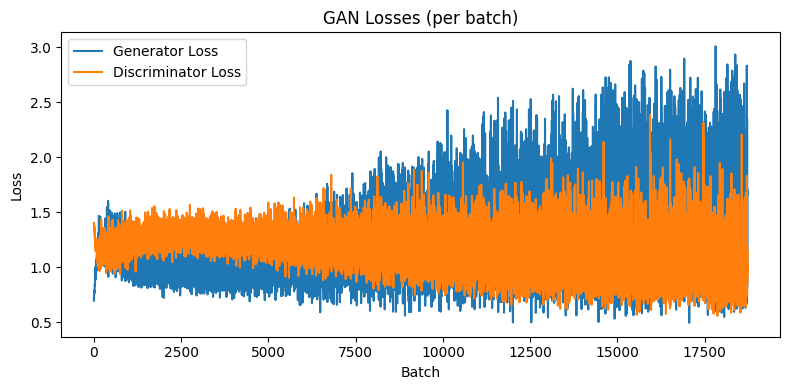

Epoch 20/20: 100%|██████████| 938/938 [02:18<00:00,  6.78it/s]


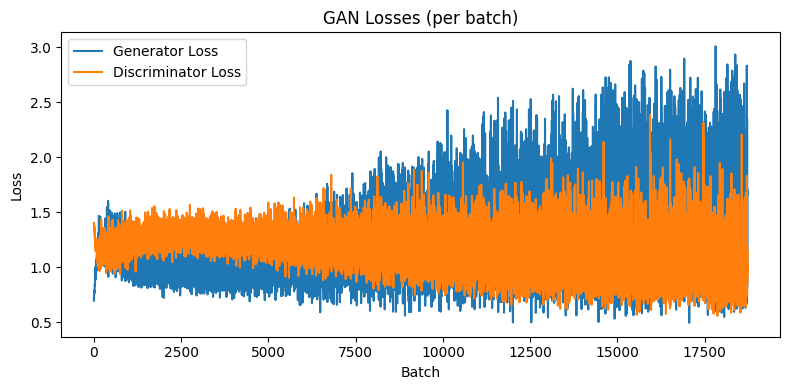

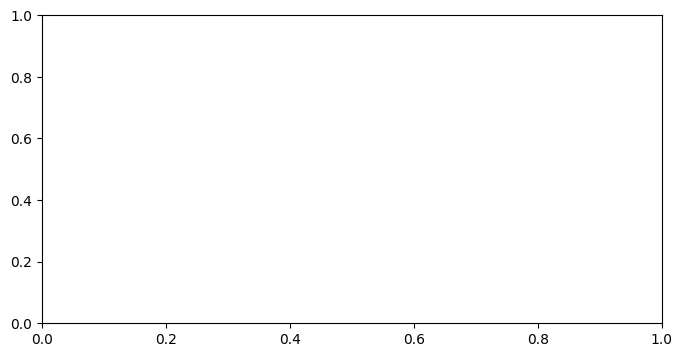

In [78]:
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython import display
import os

G_losses = []
D_losses = []

# Directory to save generated images
os.makedirs("gan_samples", exist_ok=True)

# Start the first GAN loss plot
plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))

print("Training")
start_time = t.time()

for epoch in range(epochs):
    current_time = t.time()
    print(f"Time: {current_time - start_time}")

    for i, (real_imgs, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
        batch_size = real_imgs.shape[0]
        real_imgs = real_imgs.view(batch_size, -1)

        # Label smoothing
        real_labels = torch.full((batch_size, 1), 0.9)
        fake_labels = torch.zeros(batch_size, 1)

        # Label flipping (3% of the batch)
        flip_idx = torch.rand(batch_size) < 0.03
        real_labels[flip_idx] = 0.0
        fake_labels[flip_idx] = 0.9

        # Train Discriminator
        optimizer_D.zero_grad()
        real_outputs = discriminator(real_imgs)
        real_loss = criterion(real_outputs, real_labels)

        z = torch.rand(batch_size, latent_dim)
        fake_imgs = generator(z)
        fake_outputs = discriminator(fake_imgs.detach())
        fake_loss = criterion(fake_outputs, fake_labels)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        g_loss = criterion(discriminator(fake_imgs), real_labels)
        g_loss.backward()
        optimizer_G.step()

        # Store losses for every batch
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())

        # Live plot update every 50 batches
        if i % 50 == 0:
            ax.clear()
            ax.plot(G_losses, label='Generator Loss')
            ax.plot(D_losses, label='Discriminator Loss')
            ax.set_title('GAN Losses (per batch)')
            ax.set_xlabel('Batch')
            ax.set_ylabel('Loss')
            ax.legend()
            plt.tight_layout()
            display.clear_output(wait=True)
            display.display(fig)

    # End and show the GAN loss plot for this epoch
    plt.ioff()
    plt.show()

    # Save generated images to disk (not shown interactively)
    with torch.no_grad():
        z = torch.rand(16, latent_dim)
        samples = generator(z).view(-1, 1, 28, 28)
        grid = torchvision.utils.make_grid(samples, normalize=True)
        fig_img, ax_img = plt.subplots(figsize=(4, 4))
        ax_img.imshow(grid.permute(1, 2, 0).numpy())
        ax_img.axis('off')
        ax_img.set_title(f"Generated Samples at Epoch {epoch+1}")
        plt.savefig(f"gan_samples/generated_epoch_{epoch+1}_at Time_{current_time}.png")
        plt.close(fig_img)

    # Start a new GAN loss plot for the next epoch
    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 4))

plt.ioff()
plt.show()

In [79]:
# Save models after training completion
import os

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the final trained models
final_time = t.time()
model_save_path = f"models/gan_final_at_time_{final_time:.2f}.pth"

torch.save({
    'generator_state_dict': generator.state_dict(),
    'discriminator_state_dict': discriminator.state_dict(),
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict(),
    'final_g_loss': g_loss.item(),
    'final_d_loss': d_loss.item(),
    'timestamp': final_time,
    'total_training_time': final_time - start_time,
    'epochs_trained': epochs,
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'learning_rate': lr
}, model_save_path)

print(f"Models saved to: {model_save_path}")
print(f"Total training time: {final_time - start_time:.2f} seconds")
print(f"Final Generator Loss: {g_loss.item():.4f}")
print(f"Final Discriminator Loss: {d_loss.item():.4f}")

Models saved to: models/gan_final_at_time_1753738845.87.pth
Total training time: 6124.13 seconds
Final Generator Loss: 0.9984
Final Discriminator Loss: 1.0573


In [80]:
def evaluate_gan_inception_score(generator, num_samples=5000, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Evaluate GAN performance using Inception Score.
    
    Args:
        generator: Trained generator model
        num_samples: Number of samples to generate for evaluation
        device: Device to run evaluation on
        
    Returns:
        dict: Dictionary containing evaluation metrics
    """
    from mnist_inception_score import MNISTInceptionScore

    print("Starting GAN Inception Score evaluation...")
    
    # Initialize MNIST Inception Score calculator
    is_calculator = MNISTInceptionScore(device=device)
    
    # Calculate Inception Score
    mean_is, std_is = is_calculator.calculate_inception_score(
        generator, num_samples=num_samples
    )
    
    results = {
        'inception_score_mean': mean_is,
        'inception_score_std': std_is,
        'inception_score': f"{mean_is:.3f} ± {std_is:.3f}",
        'num_samples': num_samples
    }
    
    print(f"Inception Score: {mean_is:.3f} ± {std_is:.3f}")
    print(f"Number of samples used: {num_samples}")
    
    return results

Error loading classifier: Error(s) in loading state_dict for MNISTClassifier:
	Missing key(s) in state_dict: "conv1.weight", "conv1.bias", "conv2.weight", "conv2.bias", "conv3.weight", "conv3.bias", "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias". 
	Unexpected key(s) in state_dict: "state_dict", "hyperparams", "history". 
Using untrained model.
Training
Time: 0.0002849102020263672
Final GAN evaluation...
Starting GAN Inception Score evaluation...
Error loading classifier: Error(s) in loading state_dict for MNISTClassifier:
	Missing key(s) in state_dict: "conv1.weight", "conv1.bias", "conv2.weight", "conv2.bias", "conv3.weight", "conv3.bias", "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias". 
	Unexpected key(s) in state_dict: "state_dict", "hyperparams", "history". 
Using untrained model.
Generating 5000 samples for Inception Score calculation...


Generating samples:   0%|          | 0/157 [00:00<?, ?it/s]


RuntimeError: shape '[-1, 1152]' is invalid for input of size 200704

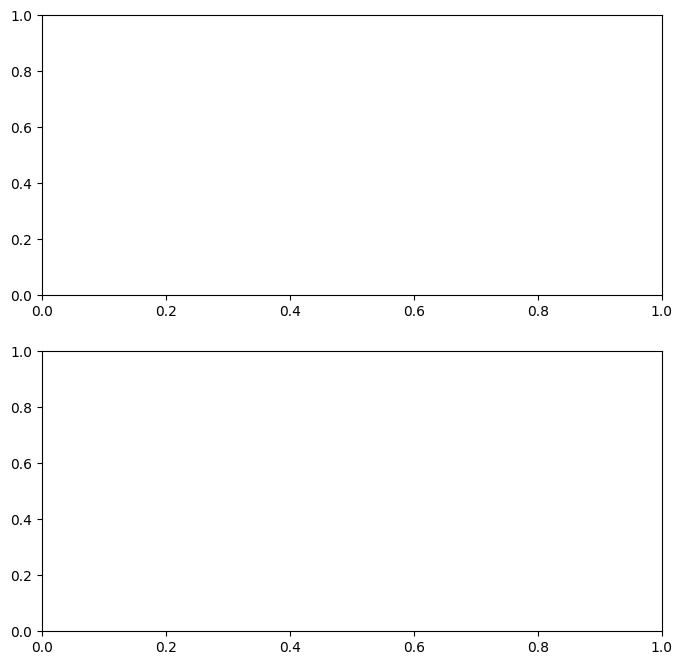

In [81]:
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython import display
import os
from mnist_inception_score import MNISTInceptionScore

G_losses = []
D_losses = []
inception_scores = []  # Store Inception Scores during training

# Directory to save generated images
os.makedirs("gan_samples", exist_ok=True)

# Initialize Inception Score calculator
is_calculator = MNISTInceptionScore(device='cuda' if torch.cuda.is_available() else 'cpu')

# Start the first GAN loss plot
plt.ion()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

print("Training")
start_time = t.time()

for epoch in range(epochs):
    current_time = t.time()
    print(f"Time: {current_time - start_time}")

    # Final evaluation
    print("Final GAN evaluation...")
    final_results = evaluate_gan_inception_score(generator, num_samples=5000)
    print(f"Final Inception Score: {final_results['inception_score']}")

    for i, (real_imgs, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
        batch_size = real_imgs.shape[0]
        real_imgs = real_imgs.view(batch_size, -1)

        # Label smoothing
        real_labels = torch.full((batch_size, 1), 0.9)
        fake_labels = torch.zeros(batch_size, 1)

        # Label flipping (3% of the batch)
        flip_idx = torch.rand(batch_size) < 0.1
        real_labels[flip_idx] = 0.0
        fake_labels[flip_idx] = 0.9

        # Train Discriminator
        optimizer_D.zero_grad()
        real_outputs = discriminator(real_imgs)
        real_loss = criterion(real_outputs, real_labels)

        z = torch.rand(batch_size, latent_dim)
        fake_imgs = generator(z)
        fake_outputs = discriminator(fake_imgs.detach())
        fake_loss = criterion(fake_outputs, fake_labels)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        g_loss = criterion(discriminator(fake_imgs), real_labels)
        g_loss.backward()
        optimizer_G.step()

        # Store losses for every batch
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())

        # Live plot update every 50 batches
        if i % 50 == 0:
            ax1.clear()
            ax1.plot(G_losses, label='Generator Loss')
            ax1.plot(D_losses, label='Discriminator Loss')
            ax1.set_title('GAN Losses (per batch)')
            ax1.set_xlabel('Batch')
            ax1.set_ylabel('Loss')
            ax1.legend()
            
            # Plot Inception Scores if available
            if inception_scores:
                ax2.clear()
                ax2.plot(inception_scores, label='Inception Score', color='green')
                ax2.set_title('Inception Score (per epoch)')
                ax2.set_xlabel('Epoch')
                ax2.set_ylabel('Inception Score')
                ax2.legend()
            
            plt.tight_layout()
            display.clear_output(wait=True)
            display.display(fig)

    # Calculate Inception Score at the end of each epoch
    print(f"Calculating Inception Score for epoch {epoch+1}...")
    mean_is, std_is = is_calculator.calculate_inception_score(generator, num_samples=1000)
    inception_scores.append(mean_is)
    print(f"Epoch {epoch+1} Inception Score: {mean_is:.3f} ± {std_is:.3f}")

    # End and show the GAN loss plot for this epoch
    plt.ioff()
    plt.show()

    # Save generated images to disk (not shown interactively)
    with torch.no_grad():
        z = torch.rand(16, latent_dim)
        samples = generator(z).view(-1, 1, 28, 28)
        grid = torchvision.utils.make_grid(samples, normalize=True)
        fig_img, ax_img = plt.subplots(figsize=(4, 4))
        ax_img.imshow(grid.permute(1, 2, 0).numpy())
        ax_img.axis('off')
        ax_img.set_title(f"Generated Samples at Epoch {epoch+1}")
        plt.savefig(f"gan_samples/generated_epoch_{epoch+1}_at Time_{current_time}.png")
        plt.close(fig_img)

    # Start a new GAN loss plot for the next epoch
    plt.ion()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

plt.ioff()
plt.show()

# Final evaluation
print("Final GAN evaluation...")
final_results = evaluate_gan_inception_score(generator, num_samples=5000)
print(f"Final Inception Score: {final_results['inception_score']}")

# Save training history
training_history = {
    'g_losses': G_losses,
    'd_losses': D_losses,
    'inception_scores': inception_scores,
    'final_inception_score': final_results['inception_score']
}
torch.save(training_history, f'training_history_at_time_{t.time():.2f}.pth')